In [ ]:
pip install pyspark

Dự báo chi phí vận chuyển

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, Imputer
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd

spark = SparkSession.builder \
    .appName("Olist_Freight_Value_Regression") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.network.timeout", "1200s") \
    .config("spark.sql.shuffle.partitions", "20") \
    .getOrCreate()

hdfs_path = "hdfs://localhost:9000/bigdata/"

items_df = spark.read.csv(hdfs_path + "olist_order_items_dataset.csv", header=True, inferSchema=True)
products_df = spark.read.csv(hdfs_path + "olist_products_dataset.csv", header=True, inferSchema=True)
orders_df = spark.read.csv(hdfs_path + "olist_orders_dataset.csv", header=True, inferSchema=True)
customers_df = spark.read.csv(hdfs_path + "olist_customers_dataset.csv", header=True, inferSchema=True)
sellers_df = spark.read.csv(hdfs_path + "olist_sellers_dataset.csv", header=True, inferSchema=True)

In [3]:
df = items_df.join(products_df, "product_id", "inner") \
             .join(sellers_df, "seller_id", "inner") \
             .join(orders_df, "order_id", "inner") \
             .join(customers_df, "customer_id", "inner")

raw_data = df.select(
    "customer_state",
    "seller_state",
    col("price").cast("double"),
    col("product_weight_g").cast("double"),
    col("product_length_cm").cast("double"),
    col("product_height_cm").cast("double"),
    col("product_width_cm").cast("double"),
    col("freight_value").cast("double").alias("label")
)

train_data, test_data = raw_data.randomSplit([0.8, 0.2], seed=42)
train_data.cache()

DataFrame[customer_state: string, seller_state: string, price: double, product_weight_g: double, product_length_cm: double, product_height_cm: double, product_width_cm: double, label: double]

In [4]:
num_cols = ["price", "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
imputer = Imputer(inputCols=num_cols, outputCols=num_cols, strategy="median")

customer_state_indexer = StringIndexer(inputCol="customer_state", outputCol="customer_state_idx", handleInvalid="keep")
seller_state_indexer = StringIndexer(inputCol="seller_state", outputCol="seller_state_idx", handleInvalid="keep")

feature_cols = num_cols + ["customer_state_idx", "seller_state_idx"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

preprocessing_stages = [imputer, customer_state_indexer, seller_state_indexer, assembler]

In [5]:
rf_regressor = RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=30, maxDepth=6, seed=42)

rf_pipeline = Pipeline(stages=preprocessing_stages + [rf_regressor])

print("Đang huấn luyện mô hình Hồi quy phân tán...")
rf_model = rf_pipeline.fit(train_data)

predictions = rf_model.transform(test_data)
predictions.select("features", "label", "prediction").show(5, truncate=False)

Đang huấn luyện mô hình Hồi quy phân tán...
+--------------------------------------+-----+------------------+
|features                              |label|prediction        |
+--------------------------------------+-----+------------------+
|[239.0,4000.0,36.0,7.0,27.0,24.0,1.0] |77.19|46.47964238181258 |
|[13.65,200.0,25.0,7.0,16.0,24.0,0.0]  |25.38|25.02210906838157 |
|[47.9,425.0,23.0,23.0,23.0,24.0,0.0]  |42.38|25.824612695448952|
|[159.99,750.0,16.0,11.0,15.0,24.0,0.0]|27.97|29.84968571143264 |
|[288.0,1400.0,16.0,19.0,15.0,19.0,6.0]|70.44|29.97019790676861 |
+--------------------------------------+-----+------------------+
only showing top 5 rows


In [7]:
evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

results = {
    "Chỉ số đánh giá (Metric)": [
        "RMSE (Sai số bình phương trung bình căn)", 
        "MAE (Sai số tuyệt đối trung bình)", 
        "R2 (Hệ số xác định)"
    ],
    "Giá trị": [rmse, mae, r2]
}

df_results = pd.DataFrame(results)
df_results.set_index("Chỉ số đánh giá (Metric)", inplace=True)

display(df_results.round(4))

,Giá trị
Chỉ số đánh giá (Metric),
RMSE (Sai số bình phương trung bình căn),9.4725
MAE (Sai số tuyệt đối trung bình),4.8818
R2 (Hệ số xác định),0.6172


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Thu thập dữ liệu dự đoán và thực tế từ tập Test về máy cục bộ
# Lệnh .toPandas() tự động chuyển Spark DataFrame thành Pandas DataFrame
results_df = predictions.select("label", "prediction").toPandas()

# Tính toán cột Sai số (Residuals) = Giá trị thực tế - Giá trị dự đoán
results_df['residuals'] = results_df['label'] - results_df['prediction']

print(f"Đã tải thành công {len(results_df)} dòng dữ liệu về Local để vẽ biểu đồ.")

Đã tải thành công 22291 dòng dữ liệu về Local để vẽ biểu đồ.


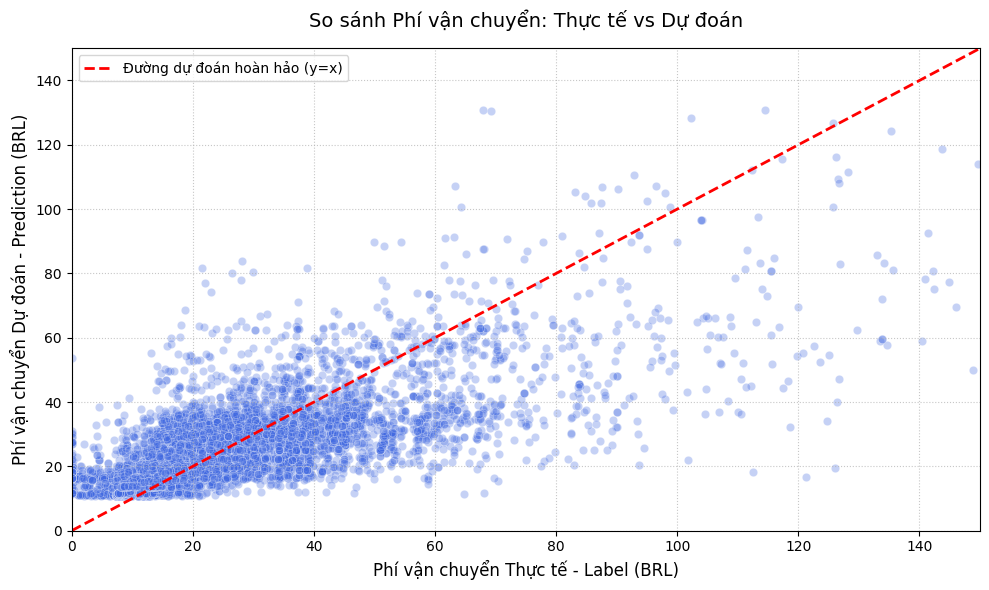

In [9]:
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ phân tán (Scatter plot) với độ trong suốt alpha=0.3 để dễ nhìn các điểm trùng nhau
sns.scatterplot(x='label', y='prediction', data=results_df, alpha=0.3, color='royalblue')

# Vẽ đường chéo chuẩn y=x (Đường màu đỏ: nơi dự đoán hoàn hảo khớp 100% với thực tế)
max_val = 150 # Lấy mốc 150 BRL để zoom vào vùng dữ liệu phổ biến nhất
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Đường dự đoán hoàn hảo (y=x)')

plt.title('So sánh Phí vận chuyển: Thực tế vs Dự đoán', fontsize=14, pad=15)
plt.xlabel('Phí vận chuyển Thực tế - Label (BRL)', fontsize=12)
plt.ylabel('Phí vận chuyển Dự đoán - Prediction (BRL)', fontsize=12)
plt.xlim(0, max_val) 
plt.ylim(0, max_val)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()